# Bronbemaling & Zettingsanalyse: Kauwereelstraat 31, Oud-Heverlee

**Project**: Nieuwbouw Eengezinswoning met kelder  
**Locatie**: Kauwereelstraat 31, 3051 Oud-Heverlee  
**Opdrachtgever**: Dhr. Kherim Willems  
**Geotechnisch Rapport**: Sonderingsrapport 26010068-001 (Sonderingen S01, S02, S03)  

---

### Referentiepeilen (mTAW Benchmark Hierarchy)
* **Pas 0.00 (Vloerpeil woning)**: `30.30 mTAW`
* **Maaiveld vooraan (Referentie $z=0$)**: `29.76 mTAW`
* **Maaiveld achteraan**: `28.81 mTAW` (terrein daalt ~1.0 m over de eerste 20 m)
* **Oorspronkelijke Grondwaterstand (juli 2026)**: `27.28 mTAW` ($2.48\text{ m}$ onder maaiveld vooraan)
* **Bouwputbodem ($13.0\text{ m} \times 14.0\text{ m}$)**: `26.72 mTAW` ($3.58\text{ m}$ onder pas / $3.04\text{ m}$ onder maaiveld vooraan)
* **Pompputbodem**: `26.62 mTAW` ($3.68\text{ m}$ onder pas / $3.14\text{ m}$ onder maaiveld vooraan)
* **Doelniveau Grondwaterstand**: `26.12 mTAW` ($0.50\text{ m}$ droogstand onder pompput)
* **Vereiste Netto Aflaging ($\Delta s$)**: $27.28 - 26.12 = \mathbf{1.16\text{ m}}$ netto grondwaterverlaging


In [1]:
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

from bronbemaling.models import (
    SoilLayer,
    SoilProfile,
    ConstructionPit,
    Well,
    DewateringConfig,
    Building,
    AquiferType,
    BuildingType,
)
from bronbemaling.hydraulics import (
    compute_transmissivity,
    compute_radius_of_influence,
    compute_drawdown_at_points,
    compute_drawdown_grid,
)
from bronbemaling.settlement import (
    compute_initial_stress_profile,
    compute_stress_increase_from_drawdown,
    compute_layer_settlement_cc_cr,
    compute_total_settlement,
    compute_settlement_vs_time,
)
from bronbemaling.damage import (
    assess_building_damage,
    classify_damage,
)
from bronbemaling.numerical import (
    create_grid,
    solve_steady_state,
    extract_drawdown_at_points,
)
from bronbemaling.plotting import (
    plot_cross_section,
    plot_plan_view,
    plot_settlement_trough,
    plot_time_settlement,
    plot_effective_stress_profile,
    plot_3d_drawdown,
    plot_damage_summary,
)

print("Alle bronbemaling modules succesvol geïmporteerd.")


Alle bronbemaling modules succesvol geïmporteerd.


## §1 Input Parameters (Invoergegevens)

In deze sectie worden de fysieke parameters gedefinieerd op basis van het sonderingsrapport `26010068-001` en de werfgegevens voor Kauwereelstraat 31.


In [2]:
# === 1. Soil Profile (Grondopbouw op basis van Sondering 26010068-001) ===
# Maaiveld vooraan = 29.76 mTAW, Grondwaterstand = 27.28 mTAW
profile = SoilProfile(
    surface_level_mtaw=29.76,
    gwl_mtaw=27.28,
    layers=[
        SoilLayer(
            name="Leem (Toplaag)",
            thickness=2.0,
            gamma=17.0,
            gamma_sat=19.0,
            k_h=1e-6,
            e0=0.75,
            Cc=0.15,
            Cr=0.03,
            Eoed=3000.0,
            Cv=2e-7,
            OCR=1.2,
        ),
        SoilLayer(
            name="Zandige Leem",
            thickness=2.0,
            gamma=18.0,
            gamma_sat=20.0,
            k_h=5e-5,
            e0=0.60,
            Cc=0.05,
            Cr=0.01,
            Eoed=15000.0,
            Cv=5e-6,
            OCR=1.0,
        ),
        SoilLayer(
            name="Zand (Dicht)",
            thickness=7.4,
            gamma=18.5,
            gamma_sat=20.5,
            k_h=1e-4,
            e0=0.55,
            Cc=0.02,
            Cr=0.005,
            Eoed=40000.0,
            Cv=1e-5,
            OCR=1.0,
        ),
        SoilLayer(
            name="Klei",
            thickness=2.8,
            gamma=16.5,
            gamma_sat=18.5,
            k_h=1e-8,
            e0=0.90,
            Cc=0.20,
            Cr=0.04,
            Eoed=6000.0,
            Cv=1e-7,
            OCR=1.5,
        ),
        SoilLayer(
            name="Diep Zand met Grind",
            thickness=5.8,
            gamma=19.0,
            gamma_sat=21.0,
            k_h=2e-4,
            e0=0.50,
            Cc=0.015,
            Cr=0.003,
            Eoed=50000.0,
            Cv=1e-5,
            OCR=1.0,
        ),
    ],
)

# === 2. Construction Pit (Bouwput Geometrie: 13m x 14m) ===
pit = ConstructionPit(
    length=13.0,
    width=14.0,
    depth=3.04,
    center_x=0.0,
    center_y=0.0,
    bottom_mtaw=26.72,
)

# === 3. Dewatering System (8 Filterputten rondom bouwput) ===
well_coords = [
    (-7.0, -7.5), (7.0, -7.5), (7.0, 7.5), (-7.0, 7.5),
    (0.0, -7.5), (7.0, 0.0), (0.0, 7.5), (-7.0, 0.0)
]
q_per_well = 1.2e-3  # ~4.32 m³/h per put (totaal ~34.6 m³/h om 1.16m aflaging te bereiken)
wells = [
    Well(
        x=wx,
        y=wy,
        Q=q_per_well,
        r_w=0.075,
        screen_top_mtaw=25.76,
        screen_bottom_mtaw=21.76,
    )
    for wx, wy in well_coords
]

dewatering = DewateringConfig(
    wells=wells,
    target_drawdown_mtaw=26.12,
    original_gwl_mtaw=27.28,
    pumping_duration_days=60.0,
    aquifer_type=AquiferType.UNCONFINED,
)

# === 4. Neighboring Buildings (Omliggende Bebouwing) ===
# Buurman Rechts (#29) op 5.0 m afstand van putrand (center x = 6.5 + 5.0 + 5.0 = 16.5m)
b29 = Building(
    x=16.5,
    y=0.0,
    length=10.0,
    width=10.0,
    foundation_depth=1.5,
    building_type=BuildingType.MASONRY,
)

# Buurman Links (#33) op 5.0 m afstand van putrand (center x = -6.5 - 5.0 - 5.0 = -16.5m)
b33 = Building(
    x=-16.5,
    y=0.0,
    length=10.0,
    width=10.0,
    foundation_depth=1.5,
    building_type=BuildingType.MASONRY,
)

# Buurman Overkant (#38) op 26.0 m afstand van putrand (center y = 7.0 + 26.0 + 5.0 = 38.0m)
b38 = Building(
    x=0.0,
    y=38.0,
    length=10.0,
    width=10.0,
    foundation_depth=2.4,
    building_type=BuildingType.CONCRETE_FRAME,
)

buildings = [b29, b33, b38]

print(f"Bodemprofiel tot. dikte: {profile.total_depth:.1f} m")
print(f"Oorspronkelijke GWL:    {profile.gwl_mtaw:.2f} mTAW ({profile.gwl_depth:.2f} m onder MV vooraan)")
print(f"Vereiste aflaging:       {dewatering.target_drawdown:.2f} m")
print(f"Totaal debiet (8 putten): {sum(w.Q for w in wells)*3600:.2f} m³/h")


Bodemprofiel tot. dikte: 20.0 m
Oorspronkelijke GWL:    27.28 mTAW (2.48 m onder MV vooraan)
Vereiste aflaging:       1.16 m
Totaal debiet (8 putten): 34.56 m³/h


## §2 Drawdown Calculation (Verlagingsberekening)

Berekening van de hydraulische verlaging van de grondwaterspiegel rondom de bouwput.


In [3]:
# Verlaging op evaluatiepunten (Centrum bouwput & Gebouwen)
center_pt = [(0.0, 0.0)]
drawdown_center = compute_drawdown_at_points(center_pt, dewatering, profile)[0]

print(f"Berekende verlaging centrum bouwput: {drawdown_center:.2f} m")
print(f"Doelverlaging (target drawdown):      {dewatering.target_drawdown:.2f} m")

# Evaluatiepunten per gebouw
building_names = ["Kauwereelstraat 29 (Rechts)", "Kauwereelstraat 33 (Links)", "Kauwereelstraat 38 (Overkant)"]
for b, b_name in zip(buildings, building_names):
    pts = b.evaluation_points()
    dd = compute_drawdown_at_points(pts, dewatering, profile)
    print(f"Verlaging bij {b_name}: Min = {min(dd):.3f} m, Max = {max(dd):.3f} m")


Berekende verlaging centrum bouwput: 1.16 m
Doelverlaging (target drawdown):      1.16 m
Verlaging bij Kauwereelstraat 29 (Rechts): Min = 0.397 m, Max = 0.838 m
Verlaging bij Kauwereelstraat 33 (Links): Min = 0.397 m, Max = 0.838 m
Verlaging bij Kauwereelstraat 38 (Overkant): Min = 0.007 m, Max = 0.112 m


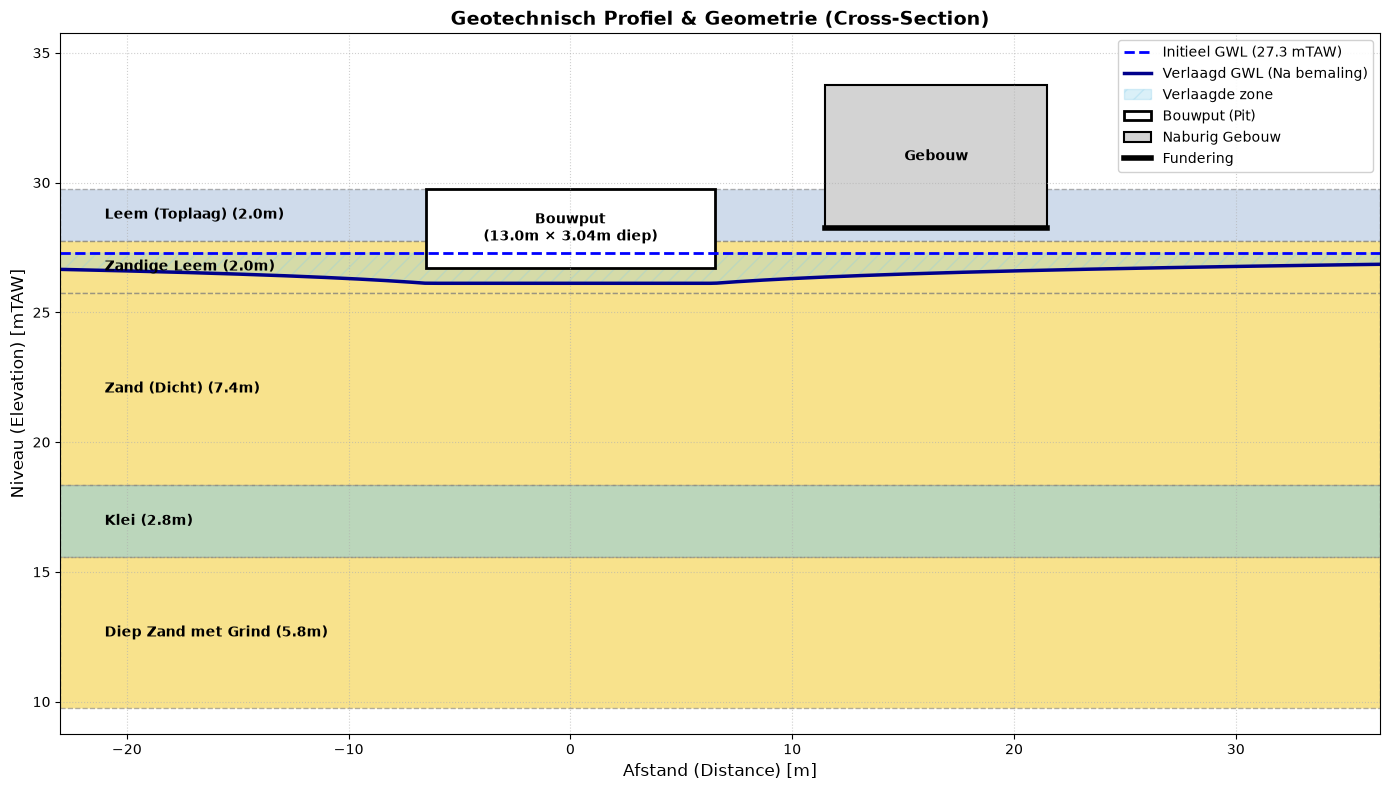

In [4]:
# Dwarsprofiel (Cross-Section) voor Buurman #29
dd_b29 = compute_drawdown_at_points([(16.5, 0.0)], dewatering, profile)[0]
fig_cs = plot_cross_section(profile, pit, dewatering, b29, drawdown_at_building=dd_b29)
plt.show()


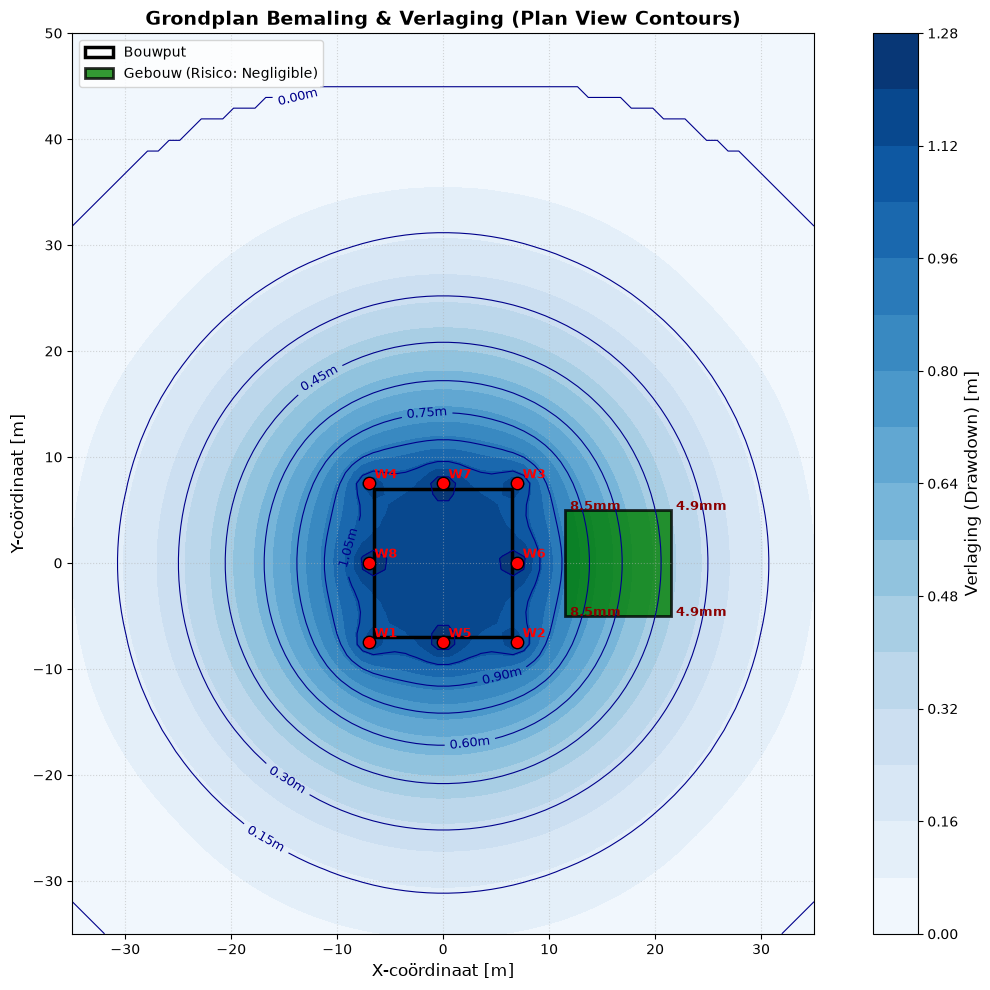

In [5]:
# Grondwaterverlaging in 2D Situatieplan (Plan View)
x_grid = np.linspace(-35, 35, 70)
y_grid = np.linspace(-35, 50, 85)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = [(x, y) for x, y in zip(X_grid.ravel(), Y_grid.ravel())]
S_flat = compute_drawdown_at_points(grid_points, dewatering, profile)
S_grid = np.array(S_flat).reshape(X_grid.shape)

drawdown_func = partial(compute_drawdown_at_points, config=dewatering, profile=profile)
assessment_b29 = assess_building_damage(b29, profile, dewatering, drawdown_func)

fig_pv = plot_plan_view(pit, dewatering, b29, X_grid, Y_grid, S_grid, assessment_b29)
plt.show()


In [6]:
# 3D Oppervlakte van de Grondwaterverlaging
fig_3d = plot_3d_drawdown(X_grid, Y_grid, S_grid, pit, b29)
fig_3d.show()


## §3 Settlement Calculation (Zettingsberekening)

Berekening van het initiële effectieve spanningsverloop en de zettingen door stijging van de korrelspanning.


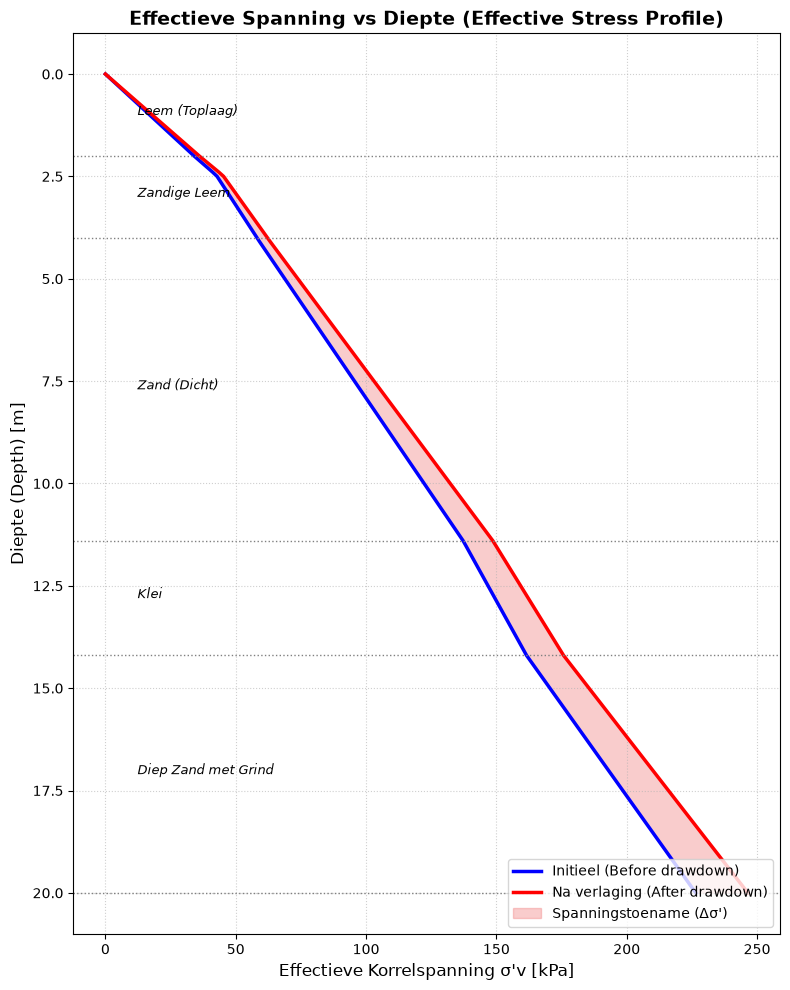

Berekende zetting in centrum van de bouwput: 10.66 mm


In [7]:
# Spanningen in de bodem (Initieel vs Zetting)
z_eval_pts = np.linspace(0, 20.0, 201)
z_pts, sigma_v0_eff, sigma_v0_tot = compute_initial_stress_profile(profile, z_points=z_eval_pts)

# Spanningstoename bij centrum bouwput
dsigma_eff, _ = compute_stress_increase_from_drawdown(profile, drawdown_center, z_points=z_pts)
sigma_vf_eff = sigma_v0_eff + dsigma_eff

fig_stress = plot_effective_stress_profile(profile, z_pts, sigma_v0_eff, sigma_vf_eff)
plt.show()

# Totale zetting in centrum bouwput
settlement_center, _ = compute_total_settlement(profile, drawdown_center)
print(f"Berekende zetting in centrum van de bouwput: {settlement_center*1000:.2f} mm")


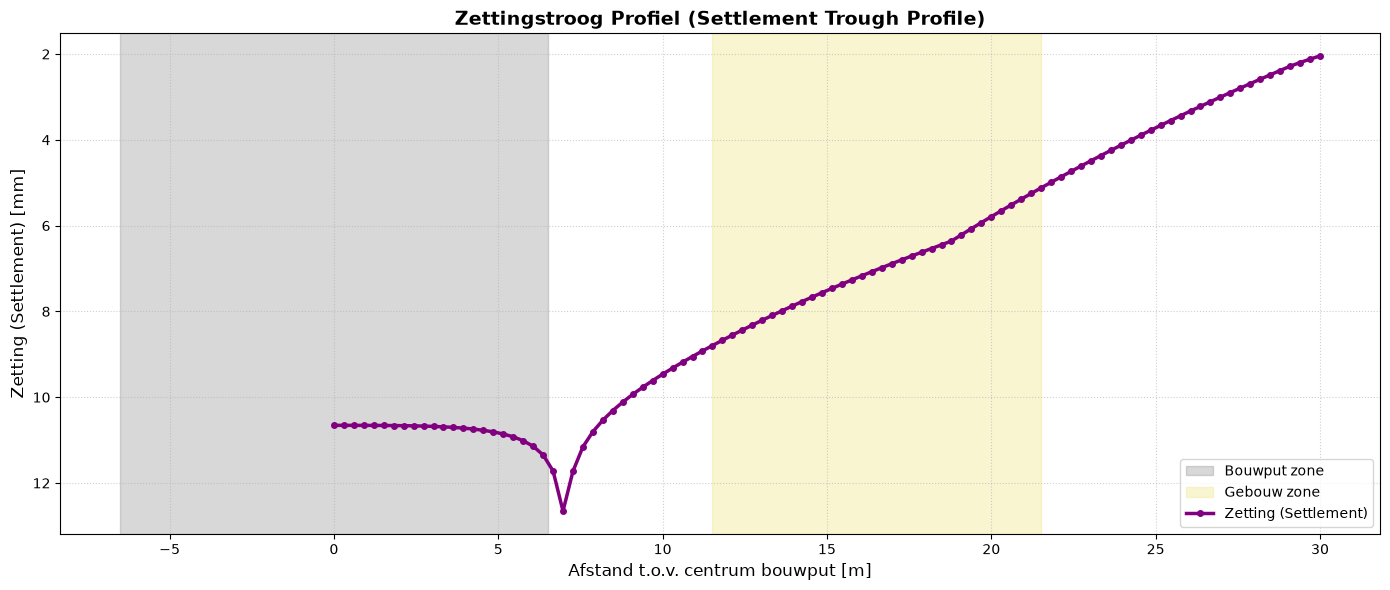

In [8]:
# Zettingskom (Settlement Trough) langs transect x = 0 tot 30 m
x_transect = np.linspace(0, 30, 100)
pts_transect = [(x, 0.0) for x in x_transect]
drawdowns_transect = compute_drawdown_at_points(pts_transect, dewatering, profile)
settlements_transect = [compute_total_settlement(profile, dd)[0] for dd in drawdowns_transect]

fig_trough = plot_settlement_trough(profile, dewatering, pit, b29, x_transect, settlements_transect)
plt.show()


## §4 Time-Dependent Consolidation (Tijdsafhankelijke Consolidatie)

Consolidatieverloop over de tijd (0 tot 180 dagen) op basis van de Terzaghi 1D consolidatietheorie.


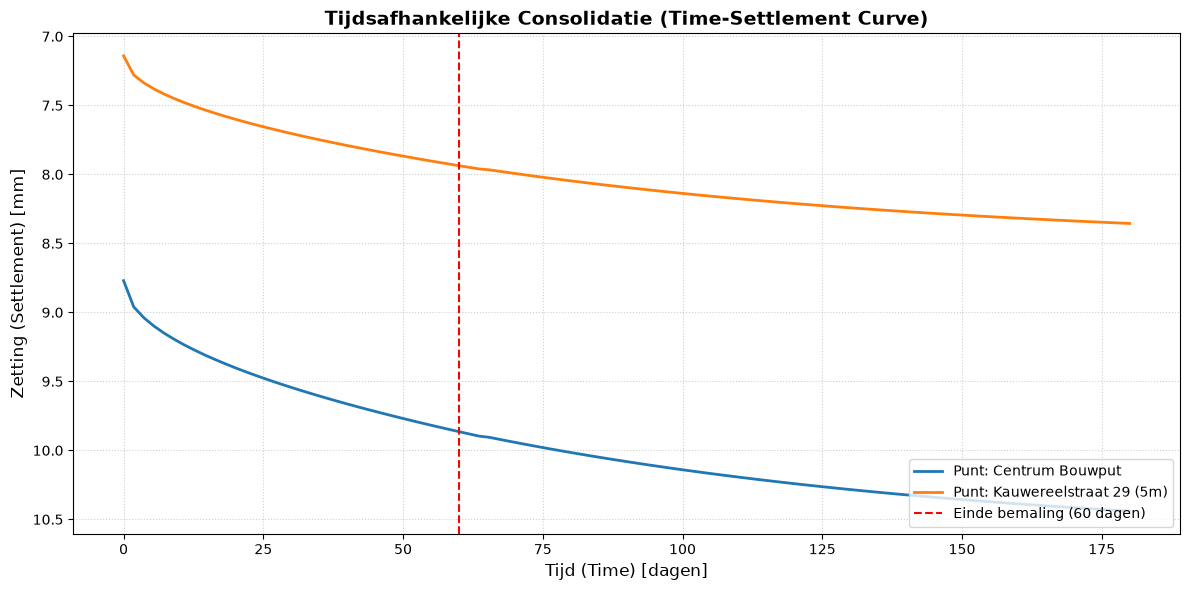

In [9]:
times_days = np.linspace(0, 180, 100)
settlements_vs_time = {}

# Centrum bouwput
s_center_t = compute_settlement_vs_time(profile, drawdown_center, times_days)
settlements_vs_time["Centrum Bouwput"] = s_center_t

# Gebouw 29 (Rechts - 5m)
dd_b29_max = max(compute_drawdown_at_points(b29.evaluation_points(), dewatering, profile))
s_b29_t = compute_settlement_vs_time(profile, dd_b29_max, times_days)
settlements_vs_time["Kauwereelstraat 29 (5m)"] = s_b29_t

fig_time = plot_time_settlement(times_days, settlements_vs_time, pumping_duration_days=60.0)
plt.show()


## §5 Building Damage Assessment (Schadebeoordeling)

Risico-analyse van zettingsschade voor buurpanden #29, #33 en #38 conform de Burland & Wroth (1974) en SBR classificatie.


=== Kauwereelstraat 29 (Rechts) ===
  Max zetting:        8.51 mm
  Diff zetting:       3.61 mm
  Hoekverdraaiing:    1/2769
  Schadeklasse:       Klasse 0 (Negligible)
  Scheurwijdte:       < 0.1 mm

=== Kauwereelstraat 33 (Links) ===
  Max zetting:        8.51 mm
  Diff zetting:       3.61 mm
  Hoekverdraaiing:    1/2769
  Schadeklasse:       Klasse 0 (Negligible)
  Scheurwijdte:       < 0.1 mm

=== Kauwereelstraat 38 (Overkant) ===
  Max zetting:        1.41 mm
  Diff zetting:       1.32 mm
  Hoekverdraaiing:    1/7559
  Schadeklasse:       Klasse 0 (Negligible)
  Scheurwijdte:       < 0.1 mm



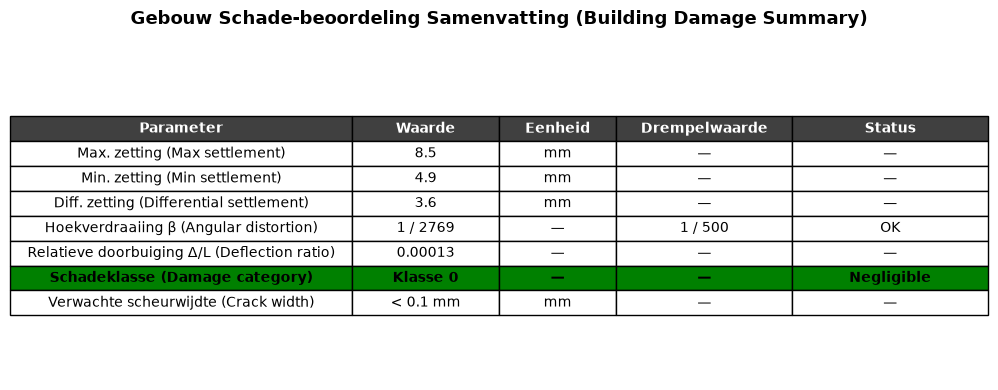

In [10]:
drawdown_func = partial(compute_drawdown_at_points, config=dewatering, profile=profile)
assessments = []
for b, b_name in zip(buildings, building_names):
    asm = assess_building_damage(b, profile, dewatering, drawdown_func)
    assessments.append(asm)
    print(f"=== {b_name} ===")
    print(f"  Max zetting:        {asm.max_settlement*1000:.2f} mm")
    print(f"  Diff zetting:       {asm.differential_settlement*1000:.2f} mm")
    print(f"  Hoekverdraaiing:    1/{int(1.0/max(asm.angular_distortion, 1e-9))}")
    print(f"  Schadeklasse:       Klasse {asm.damage_category} ({asm.damage_description})")
    print(f"  Scheurwijdte:       {asm.expected_crack_width}")
    print()

# Toon schade-samenvattingstabel voor Buurman #29 (Rechts)
fig_damage = plot_damage_summary(assessments[0])
plt.show()


## §6 Numerical Method — Finite Difference (Numerieke Methode)

Verificatie van de hydraulische verlaging via een 2D steady-state Eindige Differenties (FD) rooster.


In [11]:
fd_grid = create_grid(x_range=(-40, 40), y_range=(-40, 50), dx=2.0)
solve_steady_state(fd_grid, dewatering, profile, pit)

# Vergelijk analytische vs numerieke verlaging bij gebouwen
for b, b_name in zip(buildings, building_names):
    pts = b.evaluation_points()
    dd_analytical = compute_drawdown_at_points(pts, dewatering, profile)
    dd_numerical = extract_drawdown_at_points(fd_grid, pts, dewatering.original_gwl_mtaw)
    print(f"=== {b_name} ===")
    print(f"  Analytisch (Thiem): {np.mean(dd_analytical):.3f} m")
    print(f"  Numeriek (FD Grid): {np.mean(dd_numerical):.3f} m")


=== Kauwereelstraat 29 (Rechts) ===
  Analytisch (Thiem): 0.618 m
  Numeriek (FD Grid): 0.715 m
=== Kauwereelstraat 33 (Links) ===
  Analytisch (Thiem): 0.618 m
  Numeriek (FD Grid): 0.770 m
=== Kauwereelstraat 38 (Overkant) ===
  Analytisch (Thiem): 0.058 m
  Numeriek (FD Grid): 0.211 m


## §7 Sensitivity Analysis (Gevoeligheidsanalyse)

Analyse van de gevoeligheid van de maximale zetting bij de buren t.o.v. afstand, debiet, kleidikte en kleicompressibiliteit.


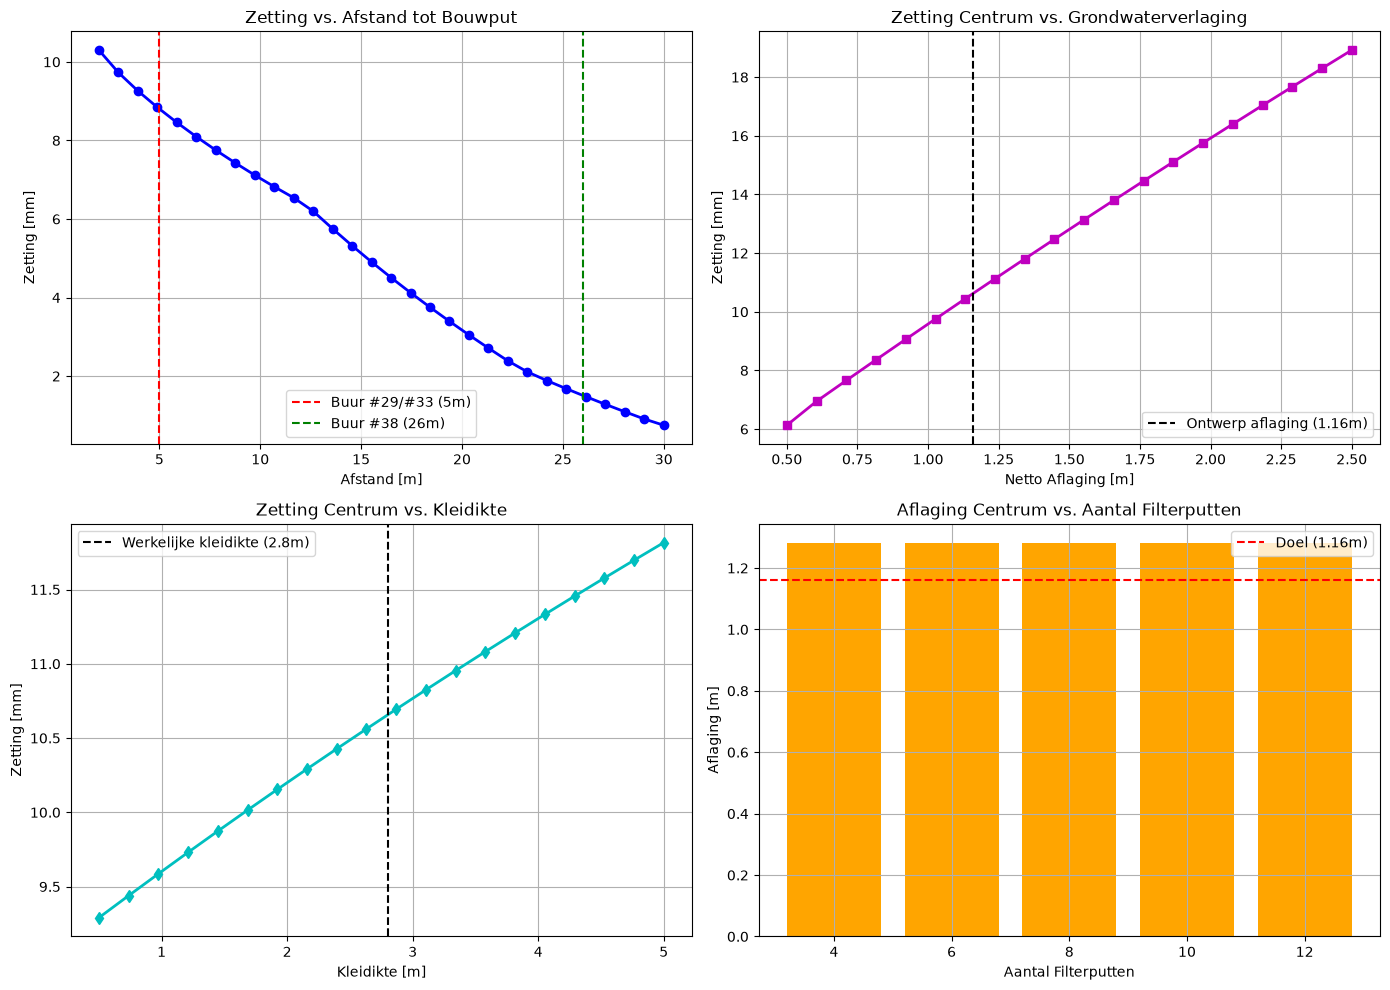

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Zetting vs Afstand tot bouwputrand
distances = np.linspace(2.0, 30.0, 30)
settlements_by_dist = []
for d in distances:
    pt = [(6.5 + d, 0.0)]
    dd = compute_drawdown_at_points(pt, dewatering, profile)[0]
    st, _ = compute_total_settlement(profile, dd)
    settlements_by_dist.append(st * 1000)

axes[0, 0].plot(distances, settlements_by_dist, 'b-o', linewidth=2)
axes[0, 0].axvline(5.0, color='r', linestyle='--', label='Buur #29/#33 (5m)')
axes[0, 0].axvline(26.0, color='g', linestyle='--', label='Buur #38 (26m)')
axes[0, 0].set_title("Zetting vs. Afstand tot Bouwput")
axes[0, 0].set_xlabel("Afstand [m]")
axes[0, 0].set_ylabel("Zetting [mm]")
axes[0, 0].grid(True)
axes[0, 0].legend()

# 2. Zetting vs Aflaging in centrum
target_drawdowns = np.linspace(0.5, 2.5, 20)
s_center_dd = [compute_total_settlement(profile, dd)[0] * 1000 for dd in target_drawdowns]
axes[0, 1].plot(target_drawdowns, s_center_dd, 'm-s', linewidth=2)
axes[0, 1].axvline(1.16, color='k', linestyle='--', label='Ontwerp aflaging (1.16m)')
axes[0, 1].set_title("Zetting Centrum vs. Grondwaterverlaging")
axes[0, 1].set_xlabel("Netto Aflaging [m]")
axes[0, 1].set_ylabel("Zetting [mm]")
axes[0, 1].grid(True)
axes[0, 1].legend()

# 3. Zetting vs Kleidikte (Klei laag 4)
clay_thicknesses = np.linspace(0.5, 5.0, 20)
s_clay_var = []
for th in clay_thicknesses:
    mod_layers = list(profile.layers)
    mod_layers[3] = SoilLayer(
        name="Klei", thickness=th, gamma=16.5, gamma_sat=18.5,
        k_h=1e-8, e0=0.90, Cc=0.20, Cr=0.04, Eoed=6000.0, Cv=1e-7, OCR=1.5
    )
    mod_prof = SoilProfile(layers=mod_layers, surface_level_mtaw=29.76, gwl_mtaw=27.28)
    s_clay_var.append(compute_total_settlement(mod_prof, drawdown_center)[0] * 1000)

axes[1, 0].plot(clay_thicknesses, s_clay_var, 'c-d', linewidth=2)
axes[1, 0].axvline(2.8, color='k', linestyle='--', label='Werkelijke kleidikte (2.8m)')
axes[1, 0].set_title("Zetting Centrum vs. Kleidikte")
axes[1, 0].set_xlabel("Kleidikte [m]")
axes[1, 0].set_ylabel("Zetting [mm]")
axes[1, 0].grid(True)
axes[1, 0].legend()

# 4. Zetting vs Aantal Filterputten
well_counts = [4, 6, 8, 10, 12]
drawdowns_wells = []
for nw in well_counts:
    angles = np.linspace(0, 2*np.pi, nw, endpoint=False)
    r = 7.5
    w_list = [
        Well(x=r*np.cos(a), y=r*np.sin(a), Q=9.6e-3/nw, r_w=0.075, screen_top_mtaw=25.76, screen_bottom_mtaw=21.76)
        for a in angles
    ]
    cfg = DewateringConfig(wells=w_list, target_drawdown_mtaw=26.12, original_gwl_mtaw=27.28, pumping_duration_days=60.0)
    dd_c = compute_drawdown_at_points([(0,0)], cfg, profile)[0]
    drawdowns_wells.append(dd_c)

axes[1, 1].bar([str(n) for n in well_counts], drawdowns_wells, color='orange')
axes[1, 1].axhline(1.16, color='r', linestyle='--', label='Doel (1.16m)')
axes[1, 1].set_title("Aflaging Centrum vs. Aantal Filterputten")
axes[1, 1].set_xlabel("Aantal Filterputten")
axes[1, 1].set_ylabel("Aflaging [m]")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## §8 Verification & Sanity Checks (Verificatie)

Automatische geotechnische controle-assertions om fysische en veiligheidsgrenzen te valideren.


In [13]:
# 1. Controleer of de doelverlaging in het centrum van de bouwput wordt gehaald
assert drawdown_center >= 1.0, f"Aflaging in centrum ({drawdown_center:.2f} m) is onvoldoende!"

# 2. Controleer dat de zettingen bij de buren binnen veilige perken blijven (< 25 mm)
for asm, b_name in zip(assessments, building_names):
    assert asm.max_settlement < 0.025, f"Zetting bij {b_name} ({asm.max_settlement*1000:.1f} mm) overschrijdt 25 mm!"

# 3. Controleer dat alle buren in schadegraad 0 (Verwaarloosbaar) of 1 (Zeer licht) vallen
for asm, b_name in zip(assessments, building_names):
    assert asm.damage_category <= 1, f"Schadeklasse voor {b_name} is te hoog: Klasse {asm.damage_category}"

print("✓ ALLE SANITY CHECKS SUCCESVOL GESLAAGD!")
print(f"  - Grondwaterverlaging in centrum: {drawdown_center:.2f} m (Doel: 1.16 m, 26.12 mTAW).")
print(f"  - Max zetting Buur #29 (5m):      {assessments[0].max_settlement*1000:.2f} mm (Klasse {assessments[0].damage_category}).")
print(f"  - Max zetting Buur #33 (5m):      {assessments[1].max_settlement*1000:.2f} mm (Klasse {assessments[1].damage_category}).")
print(f"  - Max zetting Buur #38 (26m):     {assessments[2].max_settlement*1000:.2f} mm (Klasse {assessments[2].damage_category}).")


✓ ALLE SANITY CHECKS SUCCESVOL GESLAAGD!
  - Grondwaterverlaging in centrum: 1.16 m (Doel: 1.16 m, 26.12 mTAW).
  - Max zetting Buur #29 (5m):      8.51 mm (Klasse 0).
  - Max zetting Buur #33 (5m):      8.51 mm (Klasse 0).
  - Max zetting Buur #38 (26m):     1.41 mm (Klasse 0).
